In [132]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform
import pandas as pd

# Simulation details

I first define the internal units for the simulation. I want it to be similar to a star and I want to use $N \sim 80-100$ particles, so I will set $1 \ M[IU] = 0.01 \ M_\odot = 2 \times 10^{31} \ g$ and $L \ [IU] = 1 \ R_\odot = 7 \times 10^{10} \ cm$. The time unit will be $T \ [IU] = 16035 \ s$. I will use a precision d=0.01 and print a timestamp every 0.01 IU.

# Inverse transform sampling

The pdf to sample from has the following form:

$p(\vec{x}) \propto r^2 sin(\theta) $ 

so, uniform in $\phi$, but not in $r$ and $\theta$. This is just the product of distinct distributions $p(\vec{x})=p_1(r) \cdot p_2(\theta) \cdot p_3(\phi)$. I want to sample $r \in [0.1, 2]$, $\theta \in [0, \pi]$ and $\phi \in [0, 2\pi]$. Therefore to normalize I will set:

$p_1(r) = \frac{3}{8-0.1^3} \cdot r^2$

$p_2(\theta) = \frac{1}{2} sin(\theta)$

$p_3(\phi) = \frac{1}{2\pi}$

The CDF can be computed analytically in all cases:

$H_1(r)=\frac{r^3}{8-0.1^3}$

$H_2(\theta)=-\frac{1}{2}cos(\theta)+\frac{1}{2}$

$H_3(\phi)=\frac{1}{2\pi}$

So that:

$r = [(8-0.1^3)\cdot H_1]^{\frac{1}{3}}$

$\theta = arccos(1-2H_2)$

$\phi=2\pi H_3$

Now let's sample and invert.

In [138]:
N_points = 100
dr3 = 1
y1 = uniform.rvs(0, 1, N_points)
y2 = uniform.rvs(loc=0, scale=1, size=N_points)
y3 = uniform.rvs(loc=0, scale=1, size=N_points)

r = (y1 * (dr3)) ** (1/3)
theta = np.arccos(1 - 2 * y2)
phi = 2*np.pi*y3


Text(0.5, 0, '$\\theta$ [rad]')

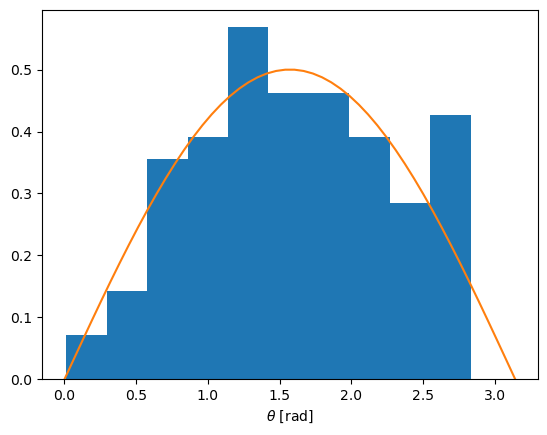

In [139]:
x= np.linspace(0,np.pi)
plt.hist(theta,density=True)
plt.plot(x,0.5*np.sin(x))
plt.xlabel(r'$\theta$ [rad]')

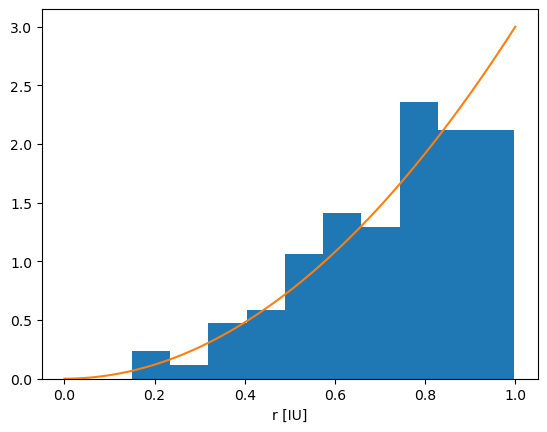

In [141]:
fig, ax = plt.subplots()
x=np.linspace(0,1)
plt.hist(r,density=True)
plt.xlabel('r [IU]')
plt.plot(x,3/(dr3)*x**2)

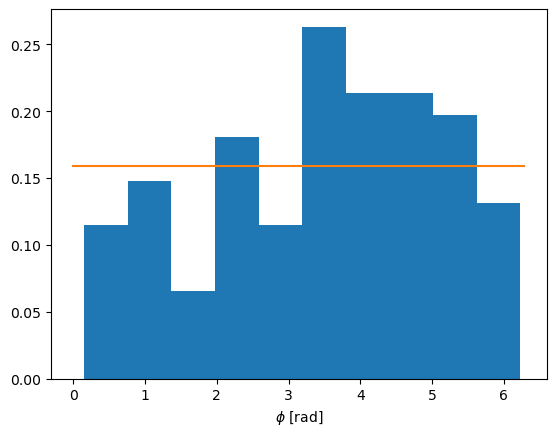

In [142]:
x=np.linspace(0,2*np.pi)
plt.hist(phi,density=True)
plt.xlabel(r'$\phi$ [rad]')
plt.plot(x,x*0+1/(2*np.pi))

Now let's turn this into (x, y, z) points and fill the initial conditions file, giving each particle a mass of 1 IU.

In [143]:
def spher_to_xyz(radius, t, p):
    x = radius * np.sin(t) * np.cos(p)
    y = radius * np.sin(t) * np.sin(p)
    z = radius * np.cos(t)
    return x, y, z

In [144]:
x_list, y_list, z_list = spher_to_xyz(r, theta, phi)
vx = np.zeros(N_points)
vy = np.zeros(N_points)
vz = np.zeros(N_points)
mass = np.ones(N_points)

# Set up initial conditions

In [145]:
cond_dict = {'m': mass, 'x': x_list, 'y': y_list, 'z': z_list, 'vx': vx, 'vy': vy, 'vz': vz}

In [146]:
def write_ic_in_file(filename, ic_dict, t0=0.0):
    '''
    filename = name of the file where you want the initial conditions
    ic_dict = dictionary containing mass, position and velocity of each particle
    t0 = start time (default=0)
    '''
    N_iter = len(ic_dict['x'])
    
    with open(filename, 'w') as f:  #first say the number of particles and the start time
        f.write(str(N_iter)+'\n')
        f.write(f"{t0:.16e}\n")
        f.close()
    
    for i in range(N_iter):
        x = ic_dict["x"][i]
        y = ic_dict['y'][i]
        z = ic_dict['z'][i]
        vx = ic_dict['vx'][i]
        vy = ic_dict['vy'][i]
        vz = ic_dict['vz'][i]
        m = ic_dict['m'][i]

        with open(filename, 'a') as f:   #append the lines; opening with 'w' overwrites the previous information
            f.write(
            f"{m:.16e} {x:.16e} {y:.16e} {z:.16e} "
            f"{vx:.16e} {vy:.16e} {vz:.16e}\n"
        )

    print('Initial conditions updated. Check your txt file.')

In [147]:
file_path = 'spher_shell_IC.txt'

write_ic_in_file(file_path, cond_dict)

Initial conditions updated. Check your txt file.


In [148]:
rho = N_points/(4*np.pi/3*dr3)
tcoll = np.sqrt(3*np.pi/(32*rho))
tcoll

0.11107207345395916

# Actual simulation & results

I estimate the collapse time to be: $T_{coll}=\sqrt{\frac{3\pi}{32G\rho_0}}$ where $\rho_0=\frac{\sum_i m_i}{V} \ (i=1...N) = 2.388 \ [IU]$, so that $T_{coll}=0.35 \ [IU]$. 

Does the simulation agree? I will let it run a little longer than the estimated collapse time, just in case.
Maybe I will change it, but for now I will assume that the distribution has collapsed when the mean r reaches its smallest value.

In [164]:
output_path = 'spher_shell_out.txt'

In [165]:
def xyz_to_r(x, y, z):
    r = np.sqrt(x**2 + y**2 + z**2)
    return r

In [166]:
data = pd.read_csv(output_path, sep=' ', header=None, names=range(7))
data.columns = ['m','x','y','z','vx','vy','vz']

time_rows = data[data.index % (N_points+2) -1 == 0]
times = (time_rows['m']) #only in the 1st lines m is the timestamp, the other 80 times it's the mass of each particle

In [167]:
print(data)
print((N_points+2)*0.16/0.005)

                m         x         y         z        vx         vy  \
0      100.000000       NaN       NaN       NaN       NaN        NaN   
1        0.001182       NaN       NaN       NaN       NaN        NaN   
2        1.000000  0.440292  0.601470 -0.194667 -0.060533  -0.052662   
3        1.000000 -0.254849 -0.110286  0.623545 -0.000847  -0.036635   
4        1.000000 -0.664298 -0.558527 -0.144429  0.081058   0.094125   
...           ...       ...       ...       ...       ...        ...   
16315    1.000000 -0.075497 -0.212000  0.009122  0.045200  17.654394   
16316    1.000000  0.425033  0.145927 -0.110280  1.662284  -2.223510   
16317    1.000000 -0.029539 -0.081049  0.084901 -0.574152   9.607507   
16318    1.000000 -0.066828 -0.069595 -0.020458 -3.090151  -1.637739   
16319    1.000000  0.212272 -0.511721  0.583254  7.381301  -3.588432   

              vz  
0            NaN  
1            NaN  
2       0.001064  
3      -0.041622  
4       0.032822  
...          ...  
16

In [168]:
# for every timestamp, compute the positions of the particles.

r_values = []

for i in range(len(times)):
    
    r_timestamp = 0
    
    for j in range(N_points):
        particle_rows = data[data.index % (N_points+2) - (2+j) == 0] #sceglie le righe con posizioni e velocità
        #print(particle_rows)
        #print(len(particle_rows))
        x = particle_rows['x'][(N_points+2)*i + j+2]
        y = particle_rows['y'][(N_points+2)*i + j+2]
        z = particle_rows['z'][(N_points+2)*i + j+2]
        r = xyz_to_r(x, y, z)
        r_timestamp+=r

    mean_r = r_timestamp/N_points
    r_values.append(mean_r)

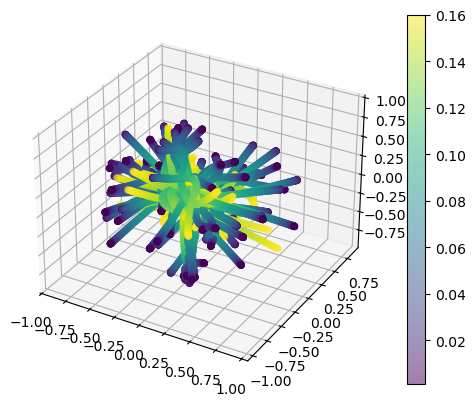

In [169]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(x,y,z)
color = times
r_s = []
for i in range(N_points):
    row = data[data.index % (N_points+2) - (2+i) == 0]
    sc = ax.scatter(row['x'],row['y'],row['z'],c=color,alpha=0.5)
    r = xyz_to_r(row['x'],row['y'],row['z'])
    r_s.append(r)
fig.colorbar(sc, ax=ax)
#print(r_s[0]) #r_s[i] dà le r della particella i-esima per ogni tempo
r_tot = []
for ti in range(len(times)):
    ri = 0
    for nj in range(N_points):
        ri+=r_s[nj].iloc[ti]
    r_tot.append(ri/N_points)

In [170]:
print(r_values)
print(r_tot)


[0.7312568262049143, 0.7311370320057478, 0.7309076402310772, 0.7306767125388413, 0.7302870717561238, 0.72988866480289, 0.7293524945290603, 0.7287634614172681, 0.7281107814085405, 0.7273376562425624, 0.7265384497429141, 0.7255946775870408, 0.7246486876008607, 0.7235852609010663, 0.7224184466656225, 0.7211565971818118, 0.7198012573280362, 0.7185091346643204, 0.7170188929942707, 0.7154931331840296, 0.7138827675963759, 0.7121989799033378, 0.7103910789033057, 0.7085346898768944, 0.7065038662870395, 0.7045306046525748, 0.7024718511226272, 0.7002722509607602, 0.6979228779060856, 0.695656418559729, 0.6932148349664429, 0.6906821471199752, 0.6881049493262853, 0.6854249460036508, 0.6826220054993748, 0.6798166698984467, 0.6768701113845395, 0.6738800555702228, 0.6707539015149894, 0.6674565701784132, 0.6641104316104273, 0.6609321491550136, 0.6575287893116851, 0.6539543375136867, 0.6503723399680942, 0.6466584842035293, 0.6428602998724429, 0.6388483923665833, 0.6349847830867226, 0.6309061014934104, 0.

In [181]:
sorted_idxs = np.argsort(r_values)
min_idx = sorted_idxs[0]
min_ind=np.argmin(r_values)
min_time = times[min_idx*(N_points+2)+1]

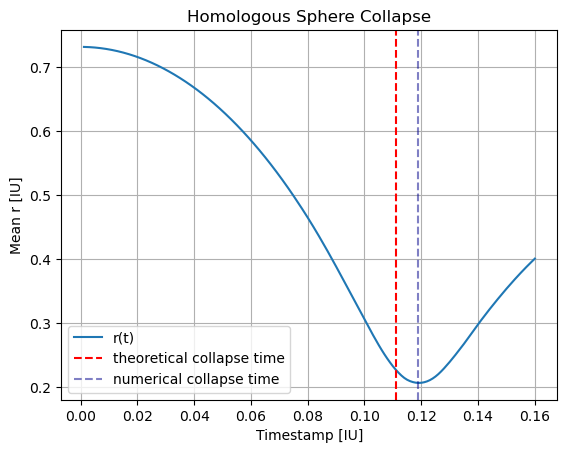

In [188]:
fig, ax = plt.subplots()
plt.plot(times, r_values,label='r(t)')
plt.xlabel('Timestamp [IU]')
plt.ylabel('Mean r [IU]')
plt.grid()
plt.axvline(tcoll,linestyle='--',c='r',alpha=1,label='theoretical collapse time')
plt.axvline(min_time,linestyle='--',c='darkblue',alpha=0.5,label='numerical collapse time')
plt.title('Homologous Sphere Collapse')
plt.legend()

In [174]:
print('Numerical result:', min_time)
print('Theoretical result:', tcoll)
print('Difference wrt theoretical result:', min_time-tcoll)
print('Relative error wrt theoretical result:', (min_time-tcoll)/tcoll)

Numerical result: 0.1190041329033326
Theoretical result: 0.11107207345395916
Difference wrt theoretical result: 0.007932059449373446
Relative error wrt theoretical result: 0.07141362542999065
